<a href="https://colab.research.google.com/github/kwanda2426/projects/blob/main/geospatial/HW_6/A5_L8_GeoAnomaly_Mazibuko.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Geo-anomaly detection** - Kwanda Mazibuko - stdnr: 1077167

# **0. Load Libraries**

In [1]:
!pip -q install yellowbrick geostatspy statsmodels geostatsmodels numba


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 3.1 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from mpl_toolkits.axes_grid1 import make_axes_locatable

from sklearn.impute import KNNImputer
from sklearn.metrics import r2_score

from statsmodels.stats.weightstats import DescrStatsW         # for weighted statistics calculations
from scipy.optimize import curve_fit                          # for curve fitting
import geostatspy.GSLIB as GSLIB                              # GSLIB utilities, visualization, and wrapper functions
import geostatspy.geostats as geostats                        # GSLIB methods converted to Python
import geostatspy                                             # for accessing the package version and general utilities
#print('GeostatsPy version: ' + str(geostatspy.__version__))   # print the version of GeostatsPy

from tqdm import tqdm                                         # progress bar for loops
from functools import partialmethod                           # used to modify tqdm to suppress the status bar
tqdm.__init__ = partialmethod(tqdm.__init__, disable=True)    # suppress the status bar for tqdm

from matplotlib.ticker import (MultipleLocator, AutoMinorLocator) # control over axes ticks in plots
plt.rc('axes', axisbelow=True)                                # ensure grid lines are plotted below plot elements

import scipy.spatial as sp                                    # for spatial data structures and algorithms (KDTree)
import geopandas as gpd                                       # for handling geospatial data (GeoDataFrame)
from matplotlib import gridspec                               # custom subplots

# Define ignore_warnings before using it
ignore_warnings = True                                        # flag to ignore warnings

# Check and apply the warning filter
if ignore_warnings == True:
    import warnings
    warnings.filterwarnings('ignore')

from IPython.utils import io                                  # mute output from simulation

cmap = "Spectral_r"


#ignoring warnings
import warnings
warnings.filterwarnings('ignore')

#making sure that we can see all rows and cols
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

# **1. Data Loading & Inspection**

In [3]:
#load data
url = "https://raw.githubusercontent.com/kwanda2426/projects/main/geospatial/HW_6/Processed_Assen_RS_data.csv"
df = pd.read_csv(url)
df.head()

,ID,Longitude,Latitude,Band1,Band2,Band3,Band4,Band5,Band6,Band7
0,0,27.564250,-25.105965,188,227,363,406,750,709,440
1,1,27.564548,-25.105963,126,144,215,166,917,479,232
2,2,27.564845,-25.105962,141,187,421,310,2263,947,438
3,3,27.565143,-25.105961,111,170,402,291,2558,1154,562
4,4,27.565440,-25.105960,232,365,658,779,2409,2199,1319


In [4]:
df.shape

(48848, 10)

In [5]:
# Summary Stat
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,48848.0,24423.500000,14101.347312,0.000000,12211.750000,24423.500000,36635.250000,48847.000000
Longitude,48848.0,27.606466,0.024398,27.564250,27.585356,27.606466,27.627580,27.648697
Latitude,48848.0,-25.128960,0.013452,-25.152291,-25.140607,-25.128958,-25.117309,-25.105620
Band1,48848.0,251.722547,94.493587,0.000000,186.000000,245.000000,312.000000,968.000000
Band2,48848.0,316.526327,106.311331,62.000000,248.000000,312.000000,377.000000,1171.000000
Band3,48848.0,509.547433,145.656643,149.000000,436.000000,498.000000,562.000000,1834.000000
Band4,48848.0,609.615419,238.682890,121.000000,467.000000,577.000000,706.000000,2558.000000
Band5,48848.0,1648.147539,446.999961,150.000000,1382.000000,1585.000000,1865.000000,5025.000000
Band6,48848.0,1801.414490,469.584012,141.000000,1539.000000,1830.000000,2070.000000,4031.000000
Band7,48848.0,1216.814609,432.462650,102.000000,937.750000,1196.000000,1454.000000,3158.000000


In [6]:
# Missingness
df.isna().sum()

,0
ID,0
Longitude,0
Latitude,0
Band1,0
Band2,0
Band3,0
Band4,0
Band5,0
Band6,0
Band7,0


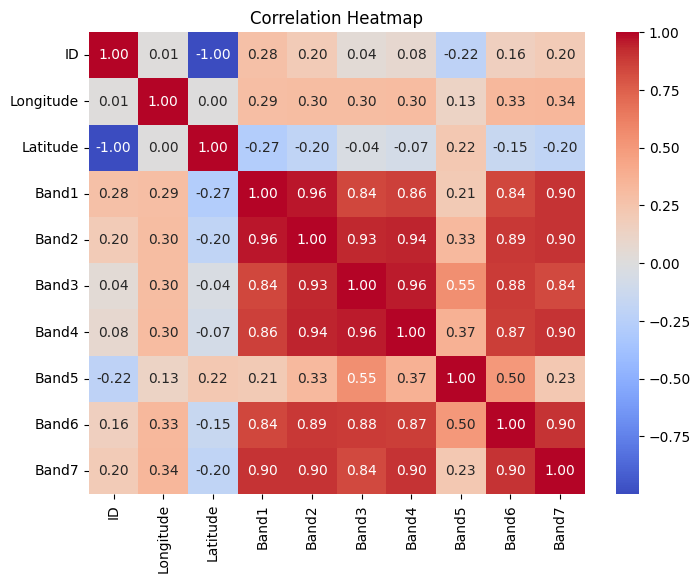

In [12]:
# correlation heatmap
corr_matrix = df.copy().corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


**Observations**

- High correlations (>= 0.85) dominate the matrix, especially among Bands 1 to 4, 6, and 7.

- Band5 stands out with consistently low correlations, indicating it captures different spectral information.

Bands 1–4, 6, and 7
These bands are strongly interrelated, with correlation coefficients mostly above 0.85.
- Band1 & Band2: 0.96
- Band3 & Band4: 0.96
- Band6 & Band7: 0.90

This means that these bands they may be capturing similar features and possibly overlapping spectral ranges or redundant information.

Band5
Shows weak correlation with all other bands:
- Band1: 0.21
- Band2: 0.33
- Band4: 0.37
- Band6: 0.50

This means that Band5 is likely measuring a distinct spectral region or feature, making it valuable for complementary analysis or dimensionality reduction.

# **2. Spatial Exploratory Data Analysis**

# **3. Data pre-processing & scaling**

# **4. Regression to reconstruct B4, B5, B6**

# **5. Residual analysis (per band)**

# **6. PCA on residuals (Bands 4, 5, 6)**